# 2. Generative AI

Generative AI refers to a class of artificial intelligence models designed to create new content, such as text, images, music, or even code. These models learn patterns from existing data and use that knowledge to generate novel outputs that resemble the training data.

> Not all foundational models are generative. For example, BERT is a foundational model primarily used for understanding and processing text rather than generating it. And not all generative models are foundational. For example, a GAN trained on a specific dataset to generate images of faces is generative but not foundational, as it is specialized for a particular task and dataset.

> With the rise of large language models (LLMs) like GPT-3, generative AI has gained significant attention for its ability to produce human-like text and perform various language tasks. The concept of interacting with these models through prompts has led to the development of "prompt engineering", which focuses on crafting effective prompts to elicit desired responses from generative models.

## How Generative Models Work

Generative models work by learning the underlying distribution of the training data. They can be broadly categorized into two types: explicit density models and implicit density models.

- **Explicit Density Models**: These models explicitly define a probability distribution over the data. Examples include Variational Autoencoders (VAEs) and Normalizing Flows. They learn to model the data distribution and can generate new samples by sampling from this learned distribution.
- **Implicit Density Models**: These models do not explicitly define a probability distribution. Instead, they learn to generate data directly. Generative Adversarial Networks (GANs) are a prime example of implicit density models, where a generator network creates samples that are evaluated by a discriminator network.

> Diffusion models are explicit density models but they model the data distribution through a gradual noising and denoising process using Markov chains.

## Different Tasks Image Generative Models Can Perform
Image Generative models can perform a variety of tasks, including:
- **Unconditional Image Generation**: Creating entirely new images from Gaussian noise or random vectors.
- **Text-Guided Image Generation**: Generating images based on textual descriptions or prompts (e.g., DALL-E, Stable Diffusion).
- **Text-Guided Image-to-Image Translation**: Transforming images from one domain to another (e.g., turning sketches into photorealistic images) based on text prompts.
- **Super-Resolution**: Enhancing the resolution of low-quality images.
- **Text-Guided Image-Inpainting**: Filling in missing parts of an image given the image, the mask of the missing area, and a text prompt.
- **Text-Guided Depth to Image Translation**: Adapt parts of an image guided by a text prompt while preserving the depth structure of the original image.

## GANs (Generative Adversarial Networks)

GANs are a class of generative models that consist of two neural networks, a generator and a discriminator, which are trained simultaneously through adversarial processes. The generator creates fake data samples, while the discriminator evaluates them against real data samples. The goal is for the generator to produce data that is indistinguishable from real data, effectively "fooling" the discriminator.

We will implement a simple GAN using PyTorch to generate images similar to those in the MNIST dataset (handwritten digits).

### Import Libraries

In [1]:
import torch
from torch import nn

import math
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

torch.manual_seed(42)

device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

### Preparing the Dataset

The MNIST dataset is a collection of 70,000 handwritten digits (0-9) commonly used for training various image processing systems. It consists of 60,000 training images and 10,000 testing images, each of size 28x28 pixels in grayscale.
We need to convert the images to tensors and normalize them to the range [-1, 1] for better training performance.
> Because the image is grayscale, we use a single channel (1) instead of three channels (RGB).

> If we don't normalize the images, because they backgrounds is black (0) and the digits are white (255), most coefficients will be close to 0, leading to vanishing gradients during training.

In [2]:
train_dataset = torchvision.datasets.MNIST(
    root="./datasets",
    train=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
    download=True,
)

100.0%
100.0%
100.0%
100.0%


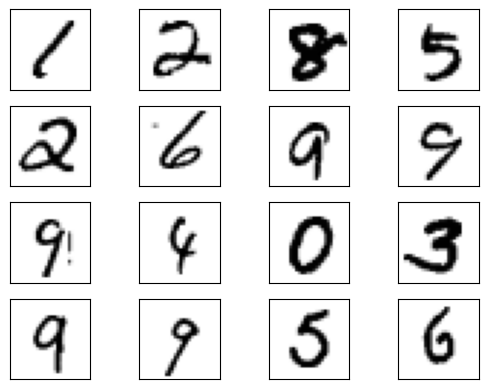

In [3]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True
)
real_samples, mnist_labels = next(iter(train_loader))
# we visualize the first 16 samples from the batch with cmap "gray_r" (black digits on white background)
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

### Implementing the GAN

### Discriminator Class

The discriminator is a neural network that takes an image as input and outputs a probability indicating whether the image is real (from the dataset) or fake (generated by the generator). It is trained to maximize the probability of correctly classifying real and fake images. The input is a 28x28 grayscale image, which we flatten into a vector of size 784 (28*28) for processing through fully connected layers.

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output

The vectorization occurs in the first line of .forward(), as the call to x.view() converts the shape of the input tensor. In this case, the original shape of the input x is 32 × 1 × 28 × 28, where 32 is the batch size you’ve set up. After the conversion, the shape of x becomes 32 × 784, with each line representing the coefficients of an image of the training set.

To run the discriminator model using the GPU, you have to instantiate it and send it to the GPU with .to(). To use a GPU when there’s one available, you can send the model to the device object you created earlier:

In [5]:
discriminator = Discriminator().to(device=device)

Since the generator is going to generate more complex data, it’s necessary to increase the dimensions of the input from the latent space. In this case, the generator is going to be fed a 100-dimensional input and will provide an output with 784 coefficients, which will be organized in a 28 × 28 tensor representing an image

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output

generator = Generator().to(device=device)

We use the hyperbolic tangent function Tanh() as the activation of the output layer since the output coefficients should be in the interval from -1 to 1.

### Training the GAN

We use as loss function the binary cross-entropy loss (BCELoss), which is suitable for binary classification tasks like distinguishing between real and fake images.

In [7]:
lr = 0.0001
num_epochs = 50
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

> In a GAN, real samples are typically labeled as 1 and generated (fake) samples as 0.
The discriminator is trained to maximize its ability to correctly classify real and fake samples.
The generator is trained to produce samples that maximize the discriminator’s probability of classifying them as real, effectively fooling the discriminator.

> The latent space is a lower-dimensional space from which the generator samples random noise vectors. During training, the generator learns a mapping from this latent space to the data space, such that points in the latent space correspond to meaningful variations in the generated samples. The dimensionality of the latent space is a hyperparameter and is typically chosen based on the complexity of the data.

In [8]:
for epoch in range(num_epochs):
    for n, (real_samples, mnist_labels) in enumerate(train_loader):
        # Data for training the discriminator
        real_samples = real_samples.to(device=device)
        real_samples_labels = torch.ones((batch_size, 1)).to(
            device=device
        )
        latent_space_samples = torch.randn((batch_size, 100)).to(
            device=device
        )
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1)).to(
            device=device
        )
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels)
        )

        # Training the discriminator
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(
            output_discriminator, all_samples_labels
        )
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator
        latent_space_samples = torch.randn((batch_size, 100)).to(
            device=device
        )

        # Training the generator
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Show loss
        if n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.522916853427887
Epoch: 0 Loss G.: 0.5465536713600159
Epoch: 1 Loss D.: 0.026697972789406776
Epoch: 1 Loss G.: 7.790037155151367
Epoch: 2 Loss D.: 0.002075838390737772
Epoch: 2 Loss G.: 6.182297706604004
Epoch: 3 Loss D.: 0.010343913920223713
Epoch: 3 Loss G.: 6.608026504516602
Epoch: 4 Loss D.: 0.037720564752817154
Epoch: 4 Loss G.: 5.090620994567871
Epoch: 5 Loss D.: 0.14569947123527527
Epoch: 5 Loss G.: 2.4320180416107178
Epoch: 6 Loss D.: 0.09198878705501556
Epoch: 6 Loss G.: 3.2792019844055176
Epoch: 7 Loss D.: 0.1693146526813507
Epoch: 7 Loss G.: 2.252645969390869
Epoch: 8 Loss D.: 0.27370551228523254
Epoch: 8 Loss G.: 2.5624945163726807
Epoch: 9 Loss D.: 0.34056541323661804
Epoch: 9 Loss G.: 1.9861118793487549
Epoch: 10 Loss D.: 0.345203161239624
Epoch: 10 Loss G.: 1.973127007484436
Epoch: 11 Loss D.: 0.3618357181549072
Epoch: 11 Loss G.: 1.5181949138641357
Epoch: 12 Loss D.: 0.40864643454551697
Epoch: 12 Loss G.: 1.9198273420333862
Epoch: 13 Loss D.: 0.370400

### Testing the GAN

To generate handwritten digits, you have to take some random samples from the latent space and feed them to the generator. The output will be a batch of images that you can visualize using matplotlib.

In [9]:
latent_space_samples = torch.randn(batch_size, 100).to(device=device)
generated_samples = generator(latent_space_samples)

But to plot generated_samples, you need to move the data back to the CPU in case it’s running on the GPU. For that, you can simply call .cpu(). As you did previously, you also need to call .detach() before using Matplotlib to plot the data

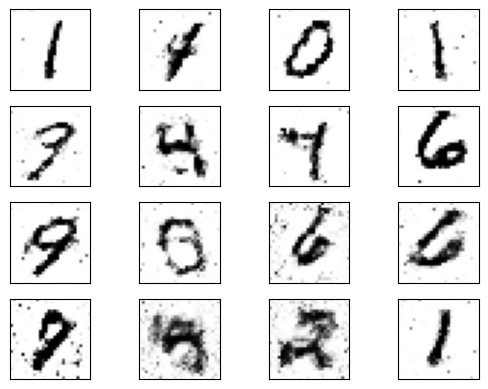

In [10]:
generated_samples = generated_samples.cpu().detach()
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

After fifty epochs of training, there are several generated digits that resemble the real ones. You can improve the results by considering more training epochs.

> By using a fixed latent space samples tensor and feeding it to the generator at the end of each epoch during the training process, you can visualize the evolution of the training

### Further reading

Refer to the [original GAN paper](https://arxiv.org/abs/1406.2661) by Ian Goodfellow et al. for a comprehensive understanding of the architecture and training process of GANs.

And the books:
- [Deep Learning with PyTorch](https://www.manning.com/books/deep-learning-with-pytorch) by Eli Stevens, Luca Antiga, and Thomas Viehmann. This book provides a solid foundation in deep learning using PyTorch.
- [GANs in Action](https://www.manning.com/books/gans-in-action) by Jakub Langr and Vladimir Bok, , covers the subject in much more detail, including recent applications such as [CycleGAN](https://junyanz.github.io/CycleGAN/) for performing style transfers.
- [Generative Deep Learning](https://www.oreilly.com/library/view/generative-deep-learning/9781492041931/) by David Foster, surveys practical applications of generative adversarial networks (GANs) and other generative models.

## Variational Autoencoders (VAEs)
Variational Autoencoders (VAEs) are a type of generative model that combines principles from autoencoders and probabilistic graphical models. VAEs consist of an encoder that maps input data to a latent space and a decoder that reconstructs the data from the latent representation. The key idea is to learn a probabilistic distribution over the latent space, allowing for the generation of new samples by sampling from this distribution.

### VAE vs GAN
- **Architecture**: VAEs consist of an encoder-decoder architecture, while GANs consist of a generator-discriminator pair.
- **Training Objective**: VAEs optimize a variational lower bound on the data likelihood, while GANs optimize a minimax game between the generator and discriminator.
- **Sample Quality**: GANs often produce sharper images, while VAEs may generate blurrier images but provide a more structured latent space.

### Further Reading
- https://medium.com/@jimwang3589/variational-autoencoder-vae-7609893c80f4
- https://www.kaggle.com/code/charel/learn-by-example-variational-autoencoder#Variational-autoencoder
- https://github.com/podgorskiy/VAE

## Diffusion Models
Diffusion models are a class of generative models that learn to generate data by reversing a diffusion process. The diffusion process gradually adds noise to the data, and the model learns to denoise it step by step, ultimately generating new samples from random noise. Diffusion models have shown impressive results in generating high-quality images and other types of data.

There are two main types of diffusion models: Denoising Diffusion Probabilistic Models (DDPMs) and Score-Based Generative Models. Both types involve a forward process that adds noise to the data and a reverse process that learns to remove the noise.

### GAN vs Diffusion Models
- **Architecture**: GANs consist of two neural networks (generator and discriminator) that compete against each other, while diffusion models typically use a single neural network to learn the denoising process.
- **Training Stability**: GANs can be challenging to train due to issues like mode collapse and instability, whereas diffusion models tend to be more stable during training.
- **Sample Quality**: Diffusion models have been shown to produce high-quality samples, often surpassing GANs in certain tasks.

### Further Reading
- [Diffusion Models Beat GANs on Image Synthesis](https://arxiv.org/abs/2105.05233) by Prafulla Dhariwal and Alexander Nichol. This paper demonstrates that diffusion models can outperform GANs in image synthesis tasks.
- https://github.com/diff-usion/Awesome-Diffusion-Models#introductory-posts
- [Hands-On Generative AI with Transformers and Diffusion Models](https://www.oreilly.com/library/view/hands-on-generative-ai/9781098149239/) by Omar Sanseviero.

> Next lab will focus on diffusion models for computer vision tasks.